In [2]:
###縫隙圖層為raster

import arcpy

# --- 參數設定區塊 ---
in_raster = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Taiwan.gdb\OL_P1_2204_Crevice_NC"
in_points = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Taiwan.gdb\Random_Points_OLP12204_NC"
out_lines = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Taiwan.gdb\OLP1_2204_Sest_lines_RandomNCP"

# 設定環境變數
arcpy.env.overwriteOutput = True
arcpy.CheckOutExtension("Spatial")

# 暫存資料路徑
temp_raster_pts = r"memory\temp_raster_pts"

try:
    print("步驟 1: 提取 Raster 中 Value = 1 的網格...")
    extracted_raster = arcpy.sa.Con(in_raster, 1, "", "Value = 1")

    print("步驟 2: 將提取出的網格轉換為點圖徵...")
    arcpy.conversion.RasterToPoint(extracted_raster, temp_raster_pts, "VALUE")

    print("步驟 3: 執行近鄰分析 (計算最短距離與目標座標)...")
    arcpy.analysis.Near(in_features=in_points, 
                        near_features=temp_raster_pts, 
                        location="LOCATION", 
                        method="PLANAR") 

    print("步驟 4: 計算輸入點的原始 XY 座標...")
    # 修正：in_features 改為 Input_Features
    arcpy.management.AddGeometryAttributes(Input_Features=in_points, 
                                           Geometry_Properties="POINT_X_Y_Z_M")

    print("步驟 5: 建立代表每個點最短距離的線圖徵...")
    sr = arcpy.Describe(in_points).spatialReference

    arcpy.management.XYToLine(in_table=in_points, 
                              out_featureclass=out_lines, 
                              startx_field="POINT_X", 
                              starty_field="POINT_Y", 
                              endx_field="NEAR_X", 
                              endy_field="NEAR_Y", 
                              line_type="PLANAR",
                              spatial_reference=sr)

    print("✅ 處理完成！")
    print("1. 最短距離已儲存於點圖徵的 [NEAR_DIST] 欄位。")
    print("2. 代表最短距離的線圖徵已成功建立。")

except arcpy.ExecuteError:
    print(f"❌ ArcGIS 執行錯誤: {arcpy.GetMessages(2)}")
except Exception as e:
    print(f"❌ 發生未預期的錯誤: {e}")

finally:
    arcpy.CheckInExtension("Spatial")
    if arcpy.Exists(temp_raster_pts):
        arcpy.management.Delete(temp_raster_pts)

步驟 1: 提取 Raster 中 Value = 1 的網格...
步驟 2: 將提取出的網格轉換為點圖徵...
步驟 3: 執行近鄰分析 (計算最短距離與目標座標)...
步驟 4: 計算輸入點的原始 XY 座標...
步驟 5: 建立代表每個點最短距離的線圖徵...
✅ 處理完成！
1. 最短距離已儲存於點圖徵的 [NEAR_DIST] 欄位。
2. 代表最短距離的線圖徵已成功建立。


Step 1: Running Near Analysis...
Step 2: Building attribute dictionary from Polygons...
Step 3: Checking and adding missing fields to points...
Step 4: Updating point attributes using dictionary...
Step 5: Generating lines and calculating geometry...
Step 6: Plotting histogram...


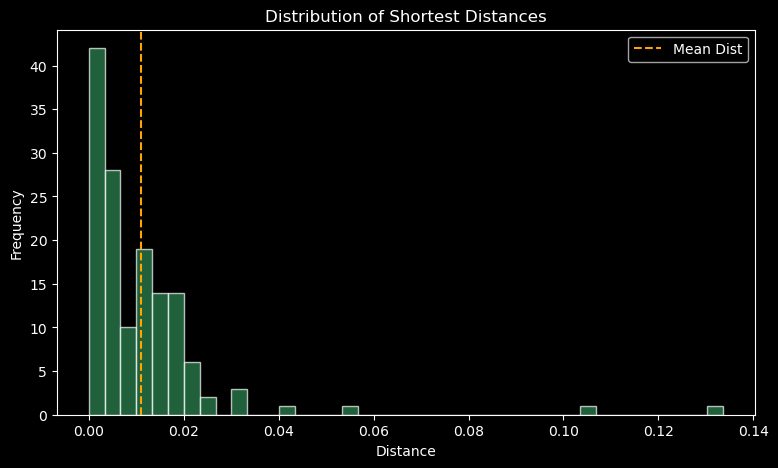

✅ Done! Data merged and visualization generated.


In [4]:
######縫隙圖層為polygon

import arcpy
import matplotlib.pyplot as plt

# --- 參數設定 ---
in_polygon = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Taiwan.gdb\OLP1_2204_crevice"
in_points = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Taiwan.gdb\Recruit_Centroids_2204"
out_lines = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Taiwan.gdb\OLP1_2204_Sest_Recruit_FromPoly"

# 需要轉移的欄位
transfer_fields = ["MEAN_VAL", "MAX_VAL", "MIN_VAL", "VAR_VAL", "MEDIAN_VAL", "AREA_M2", "PERIM_M"]

arcpy.env.overwriteOutput = True

try:
    # 步驟 1: 執行近鄰分析
    print("Step 1: Running Near Analysis...")
    arcpy.analysis.Near(in_features=in_points, 
                        near_features=in_polygon, 
                        location="LOCATION", 
                        method="PLANAR") 

    # 步驟 2: 將多邊形屬性讀入字典 (Key: OID, Value: Attributes)
    print("Step 2: Building attribute dictionary from Polygons...")
    poly_oid_name = arcpy.Describe(in_polygon).OIDFieldName
    # 構建搜尋欄位清單: [OID, MEAN_VAL, MAX_VAL, ...]
    search_fields = [poly_oid_name] + transfer_fields
    
    poly_data_dict = {}
    with arcpy.da.SearchCursor(in_polygon, search_fields) as cursor:
        for row in cursor:
            # 以 OID 為 Key，剩下的欄位內容為 Value
            poly_data_dict[row[0]] = row[1:]

    # 步驟 3: 確保點圖徵有對應的欄位 (避免 Join 改名問題)
    print("Step 3: Checking and adding missing fields to points...")
    existing_fields = [f.name for f in arcpy.ListFields(in_points)]
    fields_to_add = [[f, "DOUBLE"] for f in transfer_fields if f not in existing_fields]
    
    if fields_to_add:
        arcpy.management.AddFields(in_points, fields_to_add)

    # 步驟 4: 使用 UpdateCursor 將字典數據填入點位
    print("Step 4: Updating point attributes using dictionary...")
    # 欄位清單: [NEAR_FID, MEAN_VAL, MAX_VAL, ...]
    update_fields = ["NEAR_FID"] + transfer_fields
    
    with arcpy.da.UpdateCursor(in_points, update_fields) as cursor:
        for row in cursor:
            near_id = row[0] # 取得 NEAR_FID
            if near_id in poly_data_dict:
                # 根據字典內容更新欄位 (從索引 1 開始)
                row[1:] = poly_data_dict[near_id]
                cursor.updateRow(row)

    # 步驟 5: 計算幾何並建立線條
    print("Step 5: Generating lines and calculating geometry...")
    arcpy.management.AddGeometryAttributes(in_points, "POINT_X_Y_Z_M")
    sr = arcpy.Describe(in_points).spatialReference
    arcpy.management.XYToLine(in_points, out_lines, "POINT_X", "POINT_Y", "NEAR_X", "NEAR_Y", "PLANAR", spatial_reference=sr)

    # 步驟 6: 繪製最短距離分佈圖
    print("Step 6: Plotting histogram...")
    distances = [row[0] for row in arcpy.da.SearchCursor(in_points, ["NEAR_DIST"]) if row[0] is not None and row[0] >= 0]
    
    if distances:
        plt.figure(figsize=(9, 5))
        plt.hist(distances, bins=40, color='seagreen', edgecolor='white', alpha=0.7)
        plt.axvline(sum(distances)/len(distances), color='orange', linestyle='--', label='Mean Dist')
        plt.title("Distribution of Shortest Distances", fontsize=12)
        plt.xlabel("Distance")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

    print("✅ Done! Data merged and visualization generated.")

except Exception as e:
    print(f"❌ Error: {e}")

In [6]:
###統計縫隙密度與珊瑚覆蓋率

import arcpy
import os

# --- 1. 初始化：連結目前啟動的 Map 與 預設 GDB ---
aprx = arcpy.mp.ArcGISProject("CURRENT")
active_map = aprx.activeMap
default_gdb = aprx.defaultGeodatabase

# 環境設定
arcpy.env.overwriteOutput = True
arcpy.env.workspace = default_gdb
arcpy.CheckOutExtension("Spatial")

# 圖層名稱 (請確保這些圖層在目前 Map 的內容面板中)
raster_layer_name = "k1a_2023_GAP_F_NC"
extent_layer_name = "HW_k1a_plot_8m"
polygon_layer_name = "rr_1a_2023_coral"

# 暫存檔路徑 (建立在預設 GDB 中)
temp_extracted_crevice = os.path.join(default_gdb, "temp_crevice_extract")
erased_plot = os.path.join("memory", "erased_plot")
coral_intersect = os.path.join("memory", "coral_intersect")

def get_layer_info(layer_name):
    # 從目前 Map 尋找圖層
    layers = active_map.listLayers(layer_name)
    if not layers:
        raise Exception(f"在目前的 Map '{active_map.name}' 中找不到圖層: {layer_name}")
    
    lyr = layers[0]
    desc = arcpy.Describe(lyr)
    sr = desc.spatialReference
    
    info = {
        "name": layer_name,
        "spatial_ref": sr.name,
        "is_projected": sr.type == "Projected",
        "units": sr.linearUnitName if sr.type == "Projected" else "地理座標(度)"
    }
    
    if desc.dataType in ["RasterDataset", "RasterLayer"]:
        info["res_x"] = desc.meanCellWidth
        info["res_y"] = desc.meanCellHeight
        
    return info

try:
    # --- 2. 啟動回報 ---
    print("=" * 50)
    print(f"【專案環境報告】")
    print(f"- 目前作用中地圖: {active_map.name}")
    print(f"- 預設資料庫 (GDB): {default_gdb}")
    print("-" * 50)

    # --- 3. 圖層資訊檢查 ---
    print("【階段 1：輸入圖層檢查】")
    target_layers = [raster_layer_name, extent_layer_name, polygon_layer_name]
    layer_infos = []
    can_proceed = True

    for name in target_layers:
        info = get_layer_info(name)
        layer_infos.append(info)
        msg = f"- 圖層: {info['name']}\n  座標系: {info['spatial_ref']} ({info['units']})"
        if "res_x" in info:
            msg += f"\n  解析度: {info['res_x']:.6f} x {info['res_y']:.6f}"
        print(msg)
        
        if not info["is_projected"]:
            print(f"  ⚠️ 警告: {name} 不是投影座標系，計算面積將不準確！")
            can_proceed = False

    if not can_proceed:
        print("\n❌ 檢查未通過，請檢查座標系統是否為投影座標系後再重試。")
    else:
        print("\n✅ 檢查通過，開始執行計算...")
        print("-" * 50)

        # --- 4. 計算面積與覆蓋率 ---
        # 計算方框內的珊瑚面積
        arcpy.analysis.Intersect([extent_layer_name, polygon_layer_name], coral_intersect)
        
        plot_area = sum([row[0] for row in arcpy.da.SearchCursor(extent_layer_name, ["SHAPE@AREA"])])
        coral_area = sum([row[0] for row in arcpy.da.SearchCursor(coral_intersect, ["SHAPE@AREA"])])
        
        coral_coverage_pct = (coral_area / plot_area) * 100 if plot_area > 0 else 0
        available_area = plot_area - coral_area

        # --- 5. 處理網格資料 (排除珊瑚區域) ---
        print("正在執行空間扣除與網格分析...")
        arcpy.analysis.Erase(extent_layer_name, polygon_layer_name, erased_plot)

        # 裁切 Raster 並強制轉為整數
        extracted_raster = arcpy.sa.ExtractByMask(raster_layer_name, erased_plot)
        int_raster = arcpy.sa.Int(extracted_raster) 
        
        # 儲存至實體 GDB 以確保 BuildRasterAttributeTable 可執行
        int_raster.save(temp_extracted_crevice)

        # 獲取像素物理面積
        desc_r = arcpy.Describe(temp_extracted_crevice)
        pixel_unit_area = desc_r.meanCellWidth * desc_r.meanCellHeight

        # 更新統計數據
        arcpy.management.BuildRasterAttributeTable(temp_extracted_crevice)
        arcpy.management.CalculateStatistics(temp_extracted_crevice)
        
        crevice_count = 0
        with arcpy.da.SearchCursor(temp_extracted_crevice, ["Value", "Count"]) as cursor:
            for row in cursor:
                if row[0] == 1:
                    crevice_count = row[1]
                    break
        
        value_one_area = crevice_count * pixel_unit_area
        crevice_density = (value_one_area / available_area) if available_area > 0 else 0

        # --- 6. 輸出最終結果報告 ---
        print(f"【階段 2：分析結果報告】")
        print(f"1. 範圍方框總面積: {plot_area:.6f} m²")
        print(f"2. 珊瑚佔據面積: {coral_area:.6f} m²")
        print(f"3. 珊瑚覆蓋率 (Coral Coverage): {coral_coverage_pct:.2f}%")
        print("-" * 30)
        print(f"4. 排除珊瑚後之可用面積: {available_area:.6f} m²")
        print(f"5. Crevice (Value 1) 像素數量: {crevice_count}")
        print(f"6. Crevice 總面積: {value_one_area:.6f} m²")
        print(f"7. 剩餘底質中的 Crevice 密度: {crevice_density:.8f}")
        print("=" * 50)
        print("任務成功完成！")

except Exception as e:
    print(f"\n❌ 執行過程中發生錯誤: {e}")

finally:
    # 清理暫存資料
    print("\n正在清理暫存檔...")
    if arcpy.Exists(erased_plot): arcpy.management.Delete(erased_plot)
    if arcpy.Exists(coral_intersect): arcpy.management.Delete(coral_intersect)
    if arcpy.Exists(temp_extracted_crevice): arcpy.management.Delete(temp_extracted_crevice)
    arcpy.CheckInExtension("Spatial")

【專案環境報告】
- 目前作用中地圖: Hawaii
- 預設資料庫 (GDB): D:\ArcGIS\Morpho_Spatial_Demography\MSD_Hawaii.gdb
--------------------------------------------------
【階段 1：輸入圖層檢查】
- 圖層: k1a_2023_GAP_F_NC
  座標系: WGS_1984_UTM_Zone_4N (Meter)
  解析度: 0.001000 x 0.001000
- 圖層: HW_k1a_plot_8m
  座標系: WGS_1984_UTM_Zone_4N (Meter)
- 圖層: rr_1a_2023_coral
  座標系: WGS_1984_UTM_Zone_4N (Meter)

✅ 檢查通過，開始執行計算...
--------------------------------------------------
正在執行空間扣除與網格分析...
【階段 2：分析結果報告】
1. 範圍方框總面積: 64.000000 m²
2. 珊瑚佔據面積: 5.639195 m²
3. 珊瑚覆蓋率 (Coral Coverage): 8.81%
------------------------------
4. 排除珊瑚後之可用面積: 58.360805 m²
5. Crevice (Value 1) 像素數量: 5699372.0
6. Crevice 總面積: 5.699372 m²
7. 剩餘底質中的 Crevice 密度: 0.09765753
任務成功完成！

正在清理暫存檔...
